## DBSCAN & Hierarchical Clustering

***Week 5 - Day 2***

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [4]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
df_num = df[["Age","Annual Income (k$)", "Spending Score (1-100)"]]
df_num.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


**Step 1: Run DBSCAN on the Day 1 dataset and report how many clusters and noise points it found.**

In [8]:
scaler = MinMaxScaler()
scaler.fit(df_num[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])
X_scaled = scaler.transform(df_num[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])

X_scaled_df = pd.DataFrame(X_scaled, columns=["Age", "Annual Income (k$)", "Spending Score (1-100)"])

In [27]:
candidates = [(3, 0.15), (4, 0.15), (5, 0.15)]

for min_s, eps_val in candidates:
    db = DBSCAN(eps=eps_val, min_samples=min_s)
    labels_db = db.fit_predict(X_scaled_df)

    mask = labels_db != -1
    score = silhouette_score(X_scaled_df[mask], labels_db[mask])
    
    n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
    n_noise = list(labels_db).count(-1)
    print(f"min_samples={min_s}, eps={eps_val}: clusters={n_clusters}, noise={n_noise}, silhouette={score:.3f}")

min_samples=3, eps=0.15: clusters=3, noise=12, silhouette=0.199
min_samples=4, eps=0.15: clusters=4, noise=16, silhouette=0.131
min_samples=5, eps=0.15: clusters=3, noise=24, silhouette=0.125


In [28]:
db_final = DBSCAN(eps=0.15, min_samples=3)
labels_final = db_final.fit_predict(X_scaled_df)

n_clusters = len(set(labels_final)) - (1 if -1 in labels_final else 0)
n_noise = list(labels_final).count(-1)

print(f"final DBSCAN: clusters={n_clusters}, noise={n_noise}")

final DBSCAN: clusters=3, noise=12


I face a problem with parameters of DBSCAN, 'Cause I have a small dataset, since MinMaxScaler scale the data from 0 to 1 I done tuning on hyperparameters. the best model is with (eps=0.15, min_samples=3) so I will choose it.

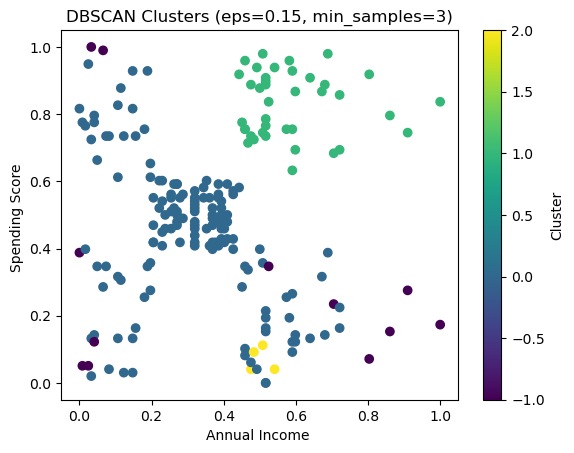

In [29]:
plt.scatter(X_scaled_df["Annual Income (k$)"], X_scaled_df["Spending Score (1-100)"], 
            c=labels_final, cmap="viridis")
plt.xlabel("Annual Income ")
plt.ylabel("Spending Score ")
plt.title("DBSCAN Clusters (eps=0.15, min_samples=3)")
plt.colorbar(label="Cluster")
plt.show()

DBSCAN found 3 main clusters in the data, plus a small group of noise points (outliers that don't fit any cluster).

**Blue cluster (large, center):** Customers with medium income and medium spending score — the biggest group, spread across most income levels.
**Green cluster (top area):** Customers with medium-to-high income and high spending score — they earn well and spend a lot.
**Yellow points (bottom):** A small tight cluster with medium income but very low spending score.
**Dark purple/noise points:** Customers scattered at the edges (very low or very high income, unusual spending patterns) that don't belong clearly to any group — DBSCAN correctly flagged them as outliers instead of forcing them into a cluster.

**Step 2: Build a hierarchical clustering dendrogram and choose a cut height, noting the resulting cluster 
count.**

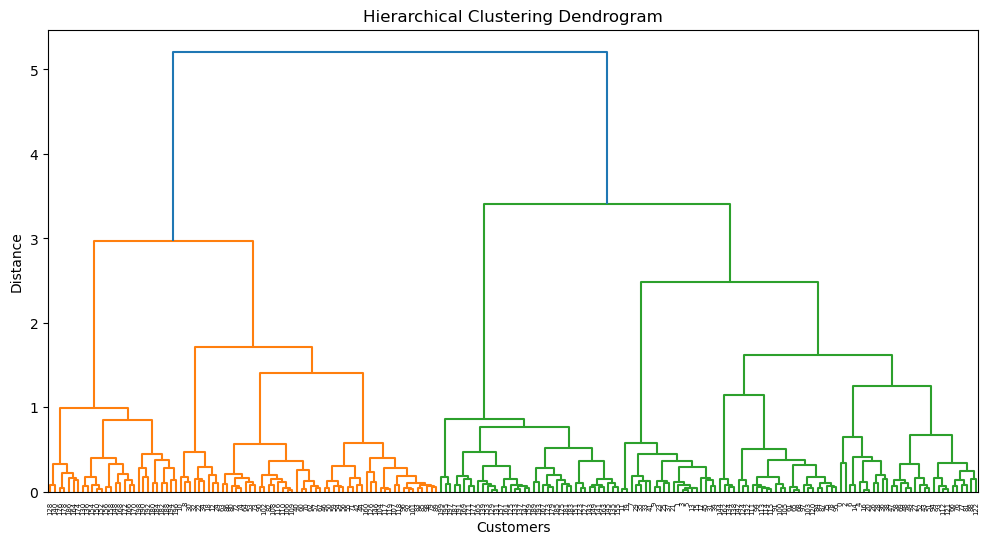

In [32]:
Z = linkage(X_scaled_df, method="ward")
plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

This tree shows how customers get grouped step by step. At the bottom, every customer starts as their own tiny cluster. As we move up, the closest customers/groups merge together — the higher two branches join, the less similar those groups are.

To pick the number of clusters, we draw an imaginary horizontal line across the tree and count how many vertical lines it crosses. That count becomes our number of clusters.

**Where to cut:** We look for the tallest vertical gap with no merges happening — that's the best place to cut, because it means the groups below that point were already stable and distinct before being forced together. In this dendrogram, that gap is around distance 2.5–3.0, which crosses about 4–5 branches — so we'll test cluster counts around there and confirm with the silhouette score.

In [34]:
for k in [3, 4, 5, 6]:
    hier_labels = fcluster(Z, k, criterion="maxclust")
    score = silhouette_score(X_scaled_df, hier_labels)
    print(f"k={k}: silhouette={score:.3f}")

k=3: silhouette=0.341
k=4: silhouette=0.365
k=5: silhouette=0.396
k=6: silhouette=0.398


In [35]:
k_final = 5
hier_labels_final = fcluster(Z, k_final, criterion="maxclust")

print(f"final num of clusters: {len(set(hier_labels_final))}")

final num of clusters: 5


I tested cluster counts from 3 to 6 using the silhouette score. The scores kept improving slightly as k increased (0.341 - 0.365 - 0.396 - 0.398), but the jump from k=5 to k=6 was tiny (only 0.002) — basically no real improvement.

I picked k=5 because it gives almost the same quality as k=6 but with a simpler, easier-to-interpret result. It also matches what we saw in the dendrogram, where there was a clear gap around distance 2.5–3.0 that splits the data into about 5 natural groups.

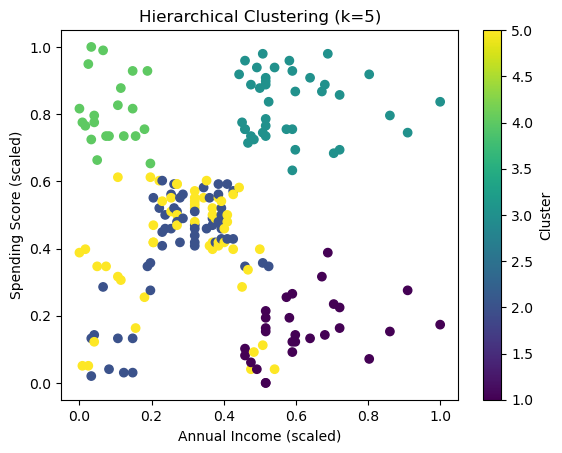

In [36]:
plt.scatter(X_scaled_df["Annual Income (k$)"], X_scaled_df["Spending Score (1-100)"], 
            c=hier_labels_final, cmap="viridis")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Hierarchical Clustering (k=5)")
plt.colorbar(label="Cluster")
plt.show()

**Step 3: Compare the K-Means, DBSCAN, and hierarchical results on the same data.**

In [37]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled_df)

print(f"KMeans clusters: {len(set(kmeans_labels))}")

KMeans clusters: 3


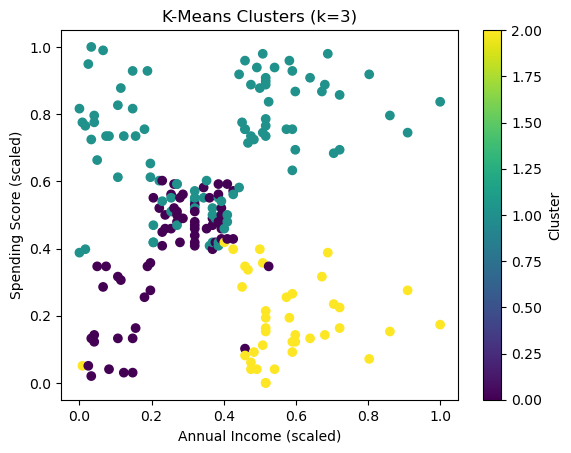

In [38]:
plt.scatter(X_scaled_df["Annual Income (k$)"], X_scaled_df["Spending Score (1-100)"], 
            c=kmeans_labels, cmap="viridis")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("K-Means Clusters (k=3)")
plt.colorbar(label="Cluster")
plt.show()

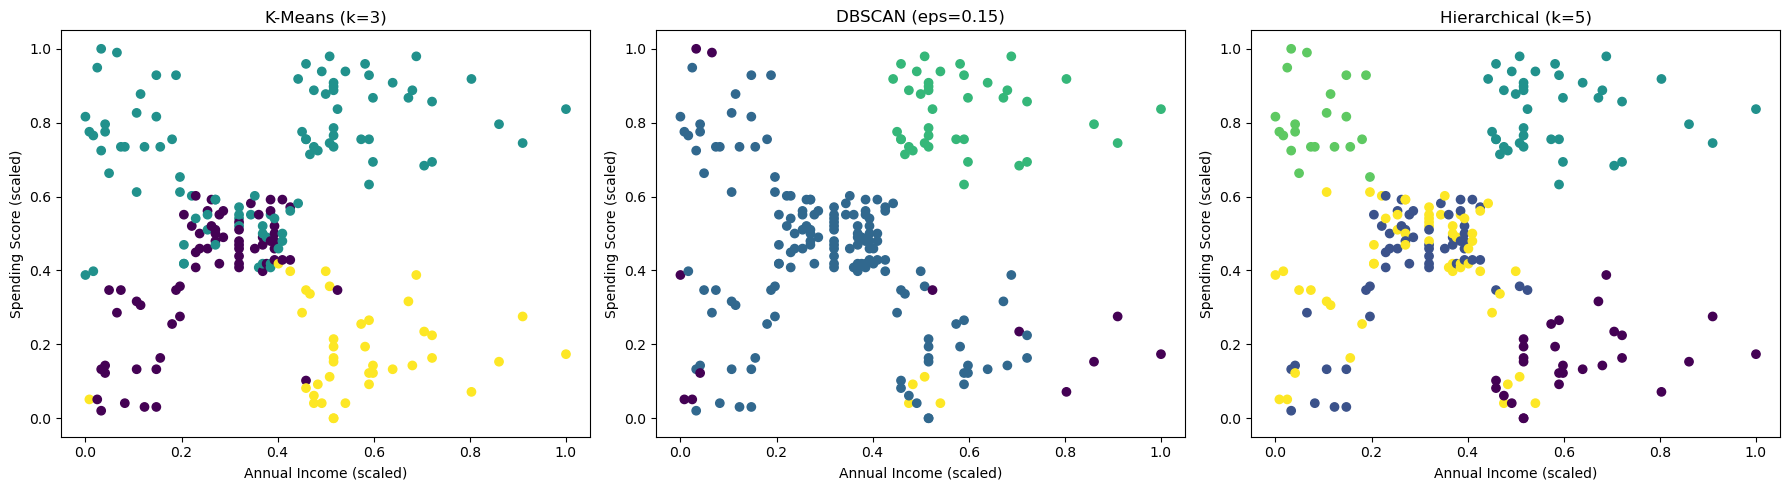

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(X_scaled_df["Annual Income (k$)"], X_scaled_df["Spending Score (1-100)"], 
                c=kmeans_labels, cmap="viridis")
axes[0].set_title("K-Means (k=3)")

axes[1].scatter(X_scaled_df["Annual Income (k$)"], X_scaled_df["Spending Score (1-100)"], 
                c=labels_final, cmap="viridis")
axes[1].set_title("DBSCAN (eps=0.15)")

axes[2].scatter(X_scaled_df["Annual Income (k$)"], X_scaled_df["Spending Score (1-100)"], 
                c=hier_labels_final, cmap="viridis")
axes[2].set_title("Hierarchical (k=5)")

for ax in axes:
    ax.set_xlabel("Annual Income (scaled)")
    ax.set_ylabel("Spending Score (scaled)")

plt.tight_layout()
plt.show()

In [40]:
methods = {
    "KMeans": kmeans_labels,
    "DBSCAN": labels_final,
    "Hierarchical": hier_labels_final
}

for name, labels in methods.items():
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if -1 in labels:
        mask = labels != -1
        score = silhouette_score(X_scaled_df[mask], labels[mask])
    else:
        score = silhouette_score(X_scaled_df, labels)
    
    print(f"{name}: clusters={n_clusters}, silhouette={score:.3f}")

KMeans: clusters=3, silhouette=0.365
DBSCAN: clusters=3, silhouette=0.199
Hierarchical: clusters=5, silhouette=0.396


Hierarchical clustering scored the best (0.396, clusters=5), followed by K-Means (0.365, clusters=3). DBSCAN scored the lowest (0.199, clusters=3) — this makes sense because DBSCAN focuses on finding dense groups and marking outliers as noise, rather than trying to maximize how separated the clusters are. K-Means and Hierarchical, on the other hand, are built to create well-separated groups, so they naturally score higher on this metric.

**Step 4: In Markdown, state which method best fits this dataset's shape and why.**

If our goal is to get the highest silhouette score, hierarchical clustering is technically the best.

But If we want something simple and easy to understand, K-Means is also a good choice — it just splits the data into slightly bigger, more general groups.

DBSCAN isn't actually worse in quality here — it's just solving a different problem. It looks for dense groups of points and marks outliers as "noise," instead of trying to make the clusters as separate as possible. So comparing it directly to the other two using silhouette score isn't really a fair comparison.